# Proyecto Phoenix: Detección de Fraude en E-Commerce
## IEEE-CIS Fraud Detection Challenge
### Grupo 2

**Equipo**: Diego Alejandro IrreÃ±o - David Fernando Lopez - Juan Camilo LÃ³pez â€“ Edda
Camila RodrÃ­guez.


**Objetivo**: El propÃ³sito es construir un modelo predictivo de detecciÃ³n de fraude en transacciones de comercio electrÃ³nico utilizando tcnicas de *Machine Learning*. Se busca identificar transacciones fraudulentas con alta precisiÃ³n para proteger tanto a comerciantes como a consumidores en el ecosistema de pagos digitales.

**Origen de los Datos**: [Datos Vesta Corporation](https://www.kaggle.com/competitions/ieee-fraud-detection/data)

**Dataset**: 590,540 transacciones con 434 variables  
**Desbalance**: 3.5% fraude, 96.5% legÃ­Â­timo



**Nota**: Nos apoyamos con herramientas IA: Copilot, GPT, Gemini para generaciÃ³n de cÃ³digo y correcciÃ³n de errores y mejora de redacciÃ³n. 
**Estructura:** Es un dataset de escala industrial compuesto por dos tablas principales: **Transacciones** (datos de pago, montos y variables anonimizadas) e **Identidad** (contexto del dispositivo y red), conectadas por el `TransactionID`.

**Volumen:** Contiene un total de **590,540 registros** y **434 variables**.

**DesafÃ­Â­o tÃ©cnico:** Presenta un alto desbalance, donde solo el **3.5%** de las transacciones son fraudulentas.

**MÃ©trica principal:** El modelo se optimiza utilizando el **AUC-ROC** (ÃƒÂrea bajo la curva de la caracterÃ­Â­stica operativa del receptor). Esta mÃ©trica es fundamental en este contexto porque permite evaluar el rendimiento del modelo en datos asimÃ©tricos o desbalanceados, donde la exactitud simple no es confiable.

---

### Datos interesantes segÃºn el anÃ¡lisis exploratorio previo (Incorporado en este notebook):

El documento destaca que ya identificaron variables crÃƒÂ­ticas que "separan" bien el fraude:

* El **Producto C** tiene la tasa mÃ¡s alta de fraude (~12%).

* Las **tarjetas de crÃ©dito** son m-as vulnerables (~7%) que las de dÃƒÂ©bito.

* El uso de **dispositivos mÃ³viles** duplica el riesgo de fraude en comparaciÃƒÂ³n con computadoras de escritorio (*desktop*).


El siguiente notebook presenta el siguiente orden, lo que permite obtener conclusiones a partir de la exploraciÃ³n inicial, limpieza, ingenierÃ­a de caracterÃ­sticas y comparaciÃ³n de varios modelos.

1. Imports e instalaciÃ³n
2. Carga de datos
3. Merge train/test con identity
4. EDA
5. Feature engineering
6. Preprocessing
7. SeparaciÃ³n X_train, y_train, X_test
8. FASE 5: SMOTE
9. Variante sin SMOTE
10. EvaluaciÃ³n/modelos
11. Stacking
12. SHAP
13. Submission
14. Guardado de modelos


---
## FASE 1: CONFIGURACIÃ“N Y CARGA DE DATOS
### Paso 1.1 y 1.2: Importar librerÃ­Â­as y cargar datos

In [1]:
%pip install -U plotly pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost imbalanced-learn shap joblib nbformat>=5.9


Note: you may need to restart the kernel to use updated packages.


In [3]:
# Data manipulation
import pandas as pd
import numpy as np
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning - Data Processing
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, auc, roc_curve, precision_recall_curve, 
    confusion_matrix, classification_report, f1_score, precision_score, recall_score
)

# Machine Learning - Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Imbalanced Learning
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import TomekLinks, EditedNearestNeighbours as ENN
from imblearn.pipeline import Pipeline as ImbPipeline

# Interpretability
import shap

# Utilities
import warnings
import joblib
from datetime import datetime

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Ã¢Å“â€œ LibrerÃƒÂ­as importadas correctamente")

Ã¢Å“â€œ LibrerÃƒÂ­as importadas correctamente


In [6]:
# Define paths
data_path = Path('./ieee-fraud-detection')

# Load datasets
print("Cargando datasets...")
train_transaction = pd.read_csv(data_path / 'train_transaction.csv')
train_identity = pd.read_csv(data_path / 'train_identity.csv')
test_transaction = pd.read_csv(data_path / 'test_transaction.csv')
test_identity = pd.read_csv(data_path / 'test_identity.csv')

print(f"Ã¢Å“â€œ train_transaction: {train_transaction.shape}")
print(f"Ã¢Å“â€œ train_identity: {train_identity.shape}")
print(f"Ã¢Å“â€œ test_transaction: {test_transaction.shape}")
print(f"Ã¢Å“â€œ test_identity: {test_identity.shape}")

Cargando datasets...


KeyboardInterrupt: 

In [ ]:
# Merge datasets
print("Mergeando datasets...")
train_data = train_transaction.merge(train_identity, on='TransactionID', how='left')
test_data = test_transaction.merge(test_identity, on='TransactionID', how='left')

print(f"Rows with identity info: {train_data['id_01'].notna().sum()} / {len(train_data)}")


print(f" train_data: {train_data.shape}")
print(f"test_data: {test_data.shape}")
print(f" Merge completado")

Mergeando datasets...
Rows with identity info: 144233 / 590540
 train_data: (590540, 434)
test_data: (506691, 433)
 Merge completado


### Paso 1.3: InspecciÃ³n inicial de datos

In [ ]:
# InformaciÃ³n general
print("=" * 60)
print("INFORMACIÃƒâ€œN GENERAL DEL DATASET")
print("=" * 60)

print(f"\nTrain shape: {train_data.shape}")
print(f"Test shape: {test_data.shape}")

print(f"\nTipos de datos:")
print(train_data.dtypes.value_counts())

print(f"\nMemoria usada: {train_data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

In [ ]:
# Primeras filas
print("Primeras 5 filas del dataset:")
print(train_data.head())

In [ ]:
# Valores faltantes
print("\nValores faltantes (Top 20):")
missing_values = train_data.isnull().sum()
missing_percent = (train_data.isnull().sum() / len(train_data)) * 100
missing_df = pd.DataFrame({
    'Columna': missing_values.index,
    'Faltantes': missing_values.values,
    'Porcentaje': missing_percent.values
}).sort_values('Porcentaje', ascending=False).head(20)

print(missing_df.to_string(index=False))

In [ ]:
# EstadÃ­Â­sticas descriptivas
print("\nEstadÃƒÂ­sticas descriptivas (variables numÃƒÂ©ricas):")
print(train_data.describe())

---
## FASE 2: ANÃLISIS EXPLORATORIO (EDA)
### Paso 2.1: AnÃ¡lisis de la variable objetivo

In [ ]:
# DistribuciÃƒÂ³n de clases
print("=" * 60)
print("DISTRIBUCIÃƒâ€œN DE LA VARIABLE OBJETIVO")
print("=" * 60)

fraud_counts = train_data['isFraud'].value_counts()
fraud_percent = train_data['isFraud'].value_counts(normalize=True) * 100

print(f"\nTotal transacciones: {len(train_data):,}")
print(f"\nLegÃƒÂ­timas (0): {fraud_counts[0]:,} ({fraud_percent[0]:.2f}%)")
print(f"Fraudulentas (1): {fraud_counts[1]:,} ({fraud_percent[1]:.2f}%)")
print(f"\nRatio desbalance: {fraud_counts[0] / fraud_counts[1]:.2f}:1")

In [ ]:
# VisualizaciÃƒÂ³n del desbalance con Matplotlib
import matplotlib.pyplot as plt

class_labels = ['LegÃƒÂ­timo', 'Fraude']
class_colors = ['#1f77b4', '#ff7f0e']

fraud_counts_plot = train_data['isFraud'].value_counts().reindex([0, 1], fill_value=0)
values = fraud_counts_plot.to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(class_labels, values, color=class_colors)
axes[0].set_title('Conteo de Transacciones')
axes[0].set_ylabel('Cantidad')

for i, value in enumerate(values):
    axes[0].text(
        i,
        value,
        f'{value:,}',
        ha='center',
        va='bottom'
    )

# Pie chart
axes[1].pie(
    values,
    labels=class_labels,
    colors=class_colors,
    autopct='%1.2f%%',
    startangle=90
)
axes[1].set_title('DistribuciÃƒÂ³n (%)')

fig.suptitle('Desbalance de Clases')
plt.tight_layout()
plt.show()

print("\nÃ¢Å“â€œ GrÃƒÂ¡fico de desbalance generado")


Transacciones por Clase

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color, name in zip([0, 1], ['steelblue', 'tomato'], ['LegÃƒÂ­timo', 'Fraude']):
    subset = train_data.loc[train_data['isFraud'] == label, 'TransactionAmt']
    axes[0].hist(
        np.log1p(subset),
        bins=60,
        alpha=0.6,
        label=name,
        color=color
    )

axes[0].set_title('DistribuciÃƒÂ³n de TransactionAmt por Clase')
axes[0].set_xlabel('log(TransactionAmt + 1)')
axes[0].set_ylabel('Cantidad')
axes[0].legend()

train_data.boxplot(
    column='TransactionAmt',
    by='isFraud',
    ax=axes[1],
    medianprops=dict(color='tomato', linewidth=2)
)

axes[1].set_yscale('log')
axes[1].set_title('TransactionAmt por Clase')
axes[1].set_xlabel('isFraud')
axes[1].set_ylabel('TransactionAmt')

plt.suptitle('')
plt.tight_layout()
plt.show()

print(train_data.groupby('isFraud')['TransactionAmt'].describe().round(2))


Fraude por variables categoricas

In [ ]:
cat_cols = ['ProductCD', 'card4', 'card6', 'DeviceType']

available_cat_cols = [col for col in cat_cols if col in train_data.columns]

fig, axes = plt.subplots(len(available_cat_cols), 1, figsize=(10, 4 * len(available_cat_cols)))

if len(available_cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, available_cat_cols):
    fraud_by_cat = (
        train_data
        .groupby(col)['isFraud']
        .agg(['count', 'mean'])
        .sort_values('mean', ascending=False)
    )

    fraud_by_cat['fraud_rate_pct'] = fraud_by_cat['mean'] * 100

    ax.bar(
        fraud_by_cat.index.astype(str),
        fraud_by_cat['fraud_rate_pct'],
        color='tomato'
    )

    ax.set_title(f'Tasa de Fraude por {col}')
    ax.set_ylabel('Fraude (%)')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=45)

    for i, value in enumerate(fraud_by_cat['fraud_rate_pct']):
        ax.text(i, value, f'{value:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()


tabla resumen de fraude por categoria

In [ ]:
for col in available_cat_cols:
    fraud_by_cat = (
        train_data
        .groupby(col)['isFraud']
        .agg(
            total='count',
            fraudes='sum',
            tasa_fraude='mean'
        )
        .sort_values('tasa_fraude', ascending=False)
    )

    fraud_by_cat['tasa_fraude'] = fraud_by_cat['tasa_fraude'] * 100

    print(f'\nTasa de fraude por {col}:')
    display(fraud_by_cat.round(2))


Volumen Diario Usando TransactionDT

In [ ]:
eda_day = train_data['TransactionDT'] // 86400

daily = train_data.groupby(eda_day)['isFraud'].agg(['count', 'sum'])
daily.index.name = 'day'
daily.columns = ['total_transacciones', 'fraudes']
daily['tasa_fraude'] = daily['fraudes'] / daily['total_transacciones'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(
    daily.index,
    daily['total_transacciones'],
    color='steelblue',
    linewidth=1
)
axes[0].set_ylabel('Total')
axes[0].set_title('Volumen Diario de Transacciones')

axes[1].plot(
    daily.index,
    daily['tasa_fraude'],
    color='tomato',
    linewidth=1
)
axes[1].set_ylabel('Fraude (%)')
axes[1].set_xlabel('Dia desde el inicio del dataset')
axes[1].set_title('Tasa Diaria de Fraude')

plt.tight_layout()
plt.show()


valores faltantes

In [ ]:
missing = (
    train_data
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_top = missing.head(30)

fig, ax = plt.subplots(figsize=(10, 8))

missing_top.sort_values().plot(
    kind='barh',
    ax=ax,
    color='slategray'
)

ax.set_title('Top 30 Variables con MÃƒÂ¡s Valores Faltantes')
ax.set_xlabel('Valores faltantes (%)')

plt.tight_layout()
plt.show()

missing_df = pd.DataFrame({
    'columna': missing.index,
    'porcentaje_faltante': missing.values
})

display(missing_df.head(30).round(2))


correlaciones numericas con isFraud

In [ ]:
exclude_cols = ['TransactionID', 'TransactionDT', 'day', 'isFraud']

num_cols = (
    train_data
    .select_dtypes(include='number')
    .columns
    .drop([col for col in exclude_cols if col in train_data.columns])
)

corr = train_data[num_cols].corrwith(train_data['isFraud']).dropna()

top_corr = pd.concat([
    corr.nlargest(15),
    corr.nsmallest(15)
]).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['tomato' if value > 0 else 'steelblue' for value in top_corr.values]

top_corr.plot(
    kind='barh',
    ax=ax,
    color=colors
)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Variables NumÃƒÂ©ricas MÃƒÂ¡s Correlacionadas con isFraud')
ax.set_xlabel('CorrelaciÃƒÂ³n de Pearson')

plt.tight_layout()
plt.show()

display(
    top_corr
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .to_frame('correlacion_con_isFraud')
    .round(4)
)


### Paso 2.2: AnÃ¡lisis por categorÃ­as clave

In [ ]:
# AnÃ¡lisis por ProductCD
print("\nTASA DE FRAUDE POR PRODUCTCD:")
fraud_by_product = train_data.groupby('ProductCD').agg({
    'isFraud': ['count', 'sum', 'mean']
}).round(4)
fraud_by_product.columns = ['Total', 'Fraudes', 'Tasa_Fraude']
fraud_by_product['Tasa_Fraude'] = fraud_by_product['Tasa_Fraude'] * 100
fraud_by_product = fraud_by_product.sort_values('Tasa_Fraude', ascending=False)
print(fraud_by_product)

In [ ]:
# AnÃ¡lisis por tipo de tarjeta (Card1, Card4, Card6)
print("\nTASA DE FRAUDE POR TIPO DE TARJETA:")
if 'card4' in train_data.columns:
    fraud_by_card = train_data.groupby('card4').agg({
        'isFraud': ['count', 'sum', 'mean']
    }).round(4)
    fraud_by_card.columns = ['Total', 'Fraudes', 'Tasa_Fraude']
    fraud_by_card['Tasa_Fraude'] = fraud_by_card['Tasa_Fraude'] * 100
    fraud_by_card = fraud_by_card.sort_values('Tasa_Fraude', ascending=False)
    print(fraud_by_card)

In [ ]:
# AnÃ¡lisis por DeviceType (Desktop vs Mobile)
print("\nTASA DE FRAUDE POR TIPO DE DISPOSITIVO:")
if 'DeviceType' in train_data.columns:
    fraud_by_device = train_data.groupby('DeviceType').agg({
        'isFraud': ['count', 'sum', 'mean']
    }).round(4)
    fraud_by_device.columns = ['Total', 'Fraudes', 'Tasa_Fraude']
    fraud_by_device['Tasa_Fraude'] = fraud_by_device['Tasa_Fraude'] * 100
    fraud_by_device = fraud_by_device.sort_values('Tasa_Fraude', ascending=False)
    print(fraud_by_device)

### Paso 2.3: AnÃ¡lisis de variables numÃ©ricas clave

In [ ]:
# TransactionAmt
print("\nCOMPARACIÃƒâ€œN DE TransactionAmt (Fraude vs LegÃ­timo):")
print("\nLegÃƒÂ­timas:")
print(train_data[train_data['isFraud'] == 0]['TransactionAmt'].describe())
print("\nFraudulentas:")
print(train_data[train_data['isFraud'] == 1]['TransactionAmt'].describe())

In [ ]:
# VisualizaciÃƒÂ³n de TransactionAmt
fig = go.Figure()

fig.add_trace(go.Box(
    y=train_data[train_data['isFraud'] == 0]['TransactionAmt'],
    name='LegÃƒÂ­tima',
    marker_color='#1f77b4'
))

fig.add_trace(go.Box(
    y=train_data[train_data['isFraud'] == 1]['TransactionAmt'],
    name='Fraude',
    marker_color='#ff7f0e'
))

fig.update_layout(title='DistribuciÃƒÂ³n de TransactionAmt por Tipo', 
                  yaxis_title='TransactionAmt', height=500)
fig.show()

### Paso 2.4 y 2.5: Correlaciones e importancia de features

In [ ]:
# CorrelaciÃƒÂ³n de variables numÃƒÂ©ricas con target
numeric_cols = train_data.select_dtypes(include=[np.number]).columns
correlations = train_data[numeric_cols].corr()['isFraud'].sort_values(ascending=False)

print("\nTOP 20 VARIABLES MÃƒÂS CORRELACIONADAS CON isFraud:")
print(correlations.head(20))

In [ ]:
# Visualizar top correlaciones
top_corr = correlations.abs().sort_values(ascending=False).head(15)
top_corr_values = correlations[top_corr.index]

fig = go.Figure(data=[
    go.Bar(x=top_corr_values.values, y=top_corr.index, orientation='h',
           marker_color=['#ff7f0e' if x > 0 else '#1f77b4' for x in top_corr_values.values])
])

fig.update_layout(title='Top 15 Variables Correlacionadas con isFraud',
                  xaxis_title='CorrelaciÃƒÂ³n', height=500, showlegend=False)
fig.show()

## FASE 3: Anàlisis de correlaciòn

---
## FASE 4: IngenierÃ­a de CaracterÃ­sticas

Esta fase se ejecuta antes del preprocessing para crear variables sobre los datos crudos: centavos del monto, variables temporales, UIDs aproximados, frequency encoding y agregaciones por grupos. 


### Preparación base del Feature Engineering

Este bloque deja `train` y `test` listos para crear variables nuevas de forma consistente. Primero se modifican nombres de columnas cambiando guiones por guiones bajos, separa `isFraud` como variable objetivo y trabaja sobre copias (`X_train_fe`, `X_test_fe`) para no perder los datos originales. Luego alinea ambas tablas agregando con `NaN` las columnas que falten en alguno de los conjuntos. Esto evita errores posteriores y garantiza que las transformaciones se apliquen con la misma estructura en entrenamiento y prueba.

In [ ]:
import gc
import numpy as np
import pandas as pd

print("Iniciando Feature Engineering...")

# Modifica nombres por si test trae columnas tipo id-01 en vez de id_01
train_data = train_data.rename(columns=lambda col: col.replace('-', '_'))
test_data = test_data.rename(columns=lambda col: col.replace('-', '_'))

y_train = train_data['isFraud'].copy()

X_train_fe = train_data.drop(columns=['isFraud']).copy()
X_test_fe = test_data.copy()

# Alinear columnas base entre train y test
for col in X_train_fe.columns:
    if col not in X_test_fe.columns:
        X_test_fe[col] = np.nan

for col in X_test_fe.columns:
    if col not in X_train_fe.columns:
        X_train_fe[col] = np.nan

X_test_fe = X_test_fe[X_train_fe.columns]

print("Columnas alineadas:")
print("X_train_fe:", X_train_fe.shape)
print("X_test_fe: ", X_test_fe.shape)


### Funciones auxiliares para crear features reutilizables

Aquí se definen tres funciones que se usarán en varios pasos de la Fase 3. `frequency_encode` convierte categorías en frecuencias relativas usando `train + test` sin usar `isFraud`, por lo que no introduce leakage del target. Se utiliza esta forma de frequency encoding acá porque muchas variables del dataset son categóricas con muchísimos valores posibles: tarjetas, direcciones, dominios de correo, dispositivos e identificadores. Si se usara one-hot encoding, se crearían demasiadas columnas y el modelo se volvería más pesado y ruidoso.


`combine_columns` construye identificadores sintéticos tipo UID combinando variables como tarjeta, dirección y dominio de correo.
 
`group_aggregate` se usa porque ayuda al modelo a entender si una transacción  es normal o anomala dentro del comportamiento historico de un  grupo. En detección de fraude no basta con saber el valor absoluto de una transacción; también importa si ese valor es coherente con el comportamiento esperado de esa tarjeta, dirección o identidad aproximada. Las agregaciones por grupo permiten capturar patrones normales de cada usuario y detectar desviaciones que pueden indicar fraude.

`group_nunique` calculan estadísticas por grupo para capturar comportamiento típico, variabilidad y consistencia de cada usuario o tarjeta.


`group_nunique` se usa para medir qué tan variable o inconsistente es el comportamiento dentro de un grupo. Asi, la idea es responder estas preguntas:

* Para una misma tarjeta, ¿cuántas direcciones distintas aparecen?
* Para una misma tarjeta + dirección, ¿cuántos dominios de correo distintos aparecen?
* Para un mismo UID, ¿cuántos montos diferentes se han usado?
 
`group_nunique` mide **consistencia**. Si hay demasiada variedad dentro de una misma identidad aproximada, eso puede ser señal de riesgo.



Se realizan estos procesos dado que en una versión inicial el feature engineering que se genero manualmente resulto  simple y aùn quedaban muchas variables, por lo que se hicieron lecturas de los notebooks de la competencia y se observo un excelente manejo en este ejercicio: https://www.kaggle.com/code/cdeotte/xgb-fraud-with-magic-0-9600#Feature-Engineering, que también refiere a este https://www.kaggle.com/code/kyakovlev/ieee-fe-with-some-eda

Interesante para el video: `group_nunique` se usa para medir **qué tan variable o inconsistente es el comportamiento dentro de un grupo**.

Mientras `group_aggregate` calcula promedios y desviaciones, `group_nunique` responde preguntas como:

```text
Para una misma tarjeta, ¿cuántas direcciones distintas aparecen?
Para una misma tarjeta + dirección, ¿cuántos dominios de correo distintos aparecen?
Para un mismo UID, ¿cuántos montos diferentes se han usado?
```

En fraude esto es útil porque el fraude muchas veces se ve como **inconsistencia**.

Por ejemplo:

```text
card1 = 12345
```

Caso normal:

```text
usa 1 o 2 direcciones
usa 1 dominio de correo
usa montos relativamente repetidos
```

Caso sospechoso:

```text
usa 15 direcciones distintas
usa muchos dominios de correo
aparece con muchas combinaciones diferentes
```

Entonces `group_nunique` crea variables como:

```python
addr1_card1_nunique
P_emaildomain_card1_addr1_nunique
TransactionAmt_card1_card2_addr1_nunique
```

La justificación sería:

> `group_nunique` permite capturar la diversidad de valores asociados a una tarjeta, dirección o UID sintético. En detección de fraude, una alta cantidad de valores únicos puede indicar comportamiento inestable, pruebas con múltiples combinaciones o uso irregular de una identidad. Por eso estas variables ayudan al modelo a diferenciar usuarios consistentes de patrones potencialmente fraudulentos.

En resumen:  
`group_nunique` mide **consistencia**. Si hay demasiada variedad dentro de una misma identidad aproximada, eso puede ser señal de riesgo.

In [ ]:
def frequency_encode(train_df, test_df, cols):
    """
    Crea frecuencia relativa usando train + test.
    No usa isFraud, entonces no hay leakage del target.
    """
    for col in cols:
        if col not in train_df.columns or col not in test_df.columns:
            continue

        combined = pd.concat([train_df[col], test_df[col]], axis=0)
        freq_map = combined.value_counts(dropna=False, normalize=True).to_dict()

        new_col = f'{col}_FE'

        train_df[new_col] = train_df[col].map(freq_map).astype('float32')
        test_df[new_col] = test_df[col].map(freq_map).astype('float32')

        print(new_col, end=', ')


def combine_columns(train_df, test_df, col1, col2):
    """
    Crea una variable combinada tipo UID.
    Ejemplo: card1 + addr1.
    """
    if col1 not in train_df.columns or col2 not in train_df.columns:
        return None

    if col1 not in test_df.columns or col2 not in test_df.columns:
        return None

    new_col = f'{col1}_{col2}'

    train_df[new_col] = (
        train_df[col1].astype(str) + '_' + train_df[col2].astype(str)
    )

    test_df[new_col] = (
        test_df[col1].astype(str) + '_' + test_df[col2].astype(str)
    )

    print(new_col, end=', ')
    return new_col


def group_aggregate(train_df, test_df, main_cols, group_cols, aggs=['mean', 'std']):
    """
    Calcula agregaciones de variables numÃƒÂ©ricas por grupos tipo UID.
    Ejemplo: promedio de TransactionAmt por card1_addr1.
    """
    for main_col in main_cols:
        if main_col not in train_df.columns or main_col not in test_df.columns:
            continue

        for group_col in group_cols:
            if group_col not in train_df.columns or group_col not in test_df.columns:
                continue

            temp = pd.concat(
                [
                    train_df[[group_col, main_col]],
                    test_df[[group_col, main_col]]
                ],
                axis=0
            )

            for agg in aggs:
                new_col = f'{main_col}_{group_col}_{agg}'

                agg_map = temp.groupby(group_col)[main_col].agg(agg).to_dict()

                train_df[new_col] = train_df[group_col].map(agg_map).astype('float32')
                test_df[new_col] = test_df[group_col].map(agg_map).astype('float32')

                train_df[new_col] = train_df[new_col].fillna(-1)
                test_df[new_col] = test_df[new_col].fillna(-1)

                print(new_col, end=', ')


def group_nunique(train_df, test_df, main_cols, group_cols):
    """
    Cuenta cuÃƒÂ¡ntos valores ÃƒÂºnicos de una variable aparecen por grupo.
    """
    for main_col in main_cols:
        if main_col not in train_df.columns or main_col not in test_df.columns:
            continue

        for group_col in group_cols:
            if group_col not in train_df.columns or group_col not in test_df.columns:
                continue

            temp = pd.concat(
                [
                    train_df[[group_col, main_col]],
                    test_df[[group_col, main_col]]
                ],
                axis=0
            )

            new_col = f'{group_col}_{main_col}_nunique'
            nunique_map = temp.groupby(group_col)[main_col].nunique().to_dict()

            train_df[new_col] = train_df[group_col].map(nunique_map).astype('float32')
            test_df[new_col] = test_df[group_col].map(nunique_map).astype('float32')

            train_df[new_col] = train_df[new_col].fillna(-1)
            test_df[new_col] = test_df[new_col].fillna(-1)

            print(new_col, end=', ')


### Features de monto y tiempo

Este bloque crea variables interpretables a partir de `TransactionAmt` y `TransactionDT`. De monto se extraen los centavos (`TransactionAmt_cents`) y una transformación logarítmica (`TransactionAmt_log`), útiles porque el fraude puede diferir entre montos redondos, montos con decimales y distribuciones muy sesgadas. De tiempo se derivan día, hora y día de la semana para capturar patrones temporales, como actividad sospechosa en ciertas horas o cambios por ciclos semanales.

In [ ]:
print("Creando features de monto...")

if 'TransactionAmt' in X_train_fe.columns:
    for df_ in [X_train_fe, X_test_fe]:
        df_['TransactionAmt_cents'] = (
            df_['TransactionAmt'] - np.floor(df_['TransactionAmt'])
        ).astype('float32')

        df_['TransactionAmt_log'] = np.log1p(df_['TransactionAmt']).astype('float32')

print("TransactionAmt_cents, TransactionAmt_log")


print("\nCreando features temporales...")

if 'TransactionDT' in X_train_fe.columns:
    seconds_per_day = 24 * 60 * 60

    for df_ in [X_train_fe, X_test_fe]:
        df_['Transaction_day'] = (df_['TransactionDT'] // seconds_per_day).astype('int16')
        df_['Transaction_hour'] = ((df_['TransactionDT'] % seconds_per_day) // 3600).astype('int8')
        df_['Transaction_weekday'] = (df_['Transaction_day'] % 7).astype('int8')

print("Transaction_day, Transaction_hour, Transaction_weekday")


### Frequency encoding de variables categóricas base

En este paso las variables categóricas clave se transforman en su frecuencia relativa de aparición. La idea es que un valor muy común represente comportamiento habitual, mientras que valores raros pueden indicar riesgo o patrones menos confiables. Se aplica a direcciones, tarjetas, dominios de correo e información de dispositivo/identidad. Como no se usa la variable objetivo, esta codificación conserva información útil sin mezclar directamente la etiqueta de fraude.

In [ ]:
print("Frequency encoding:")

freq_cols = [
    'addr1',
    'addr2',
    'card1',
    'card2',
    'card3',
    'card5',
    'P_emaildomain',
    'R_emaildomain',
    'DeviceInfo',
    'id_30',
    'id_31',
    'id_33'
]

frequency_encode(X_train_fe, X_test_fe, freq_cols)


### Combinaciones tipo UID

Este bloque crea identificadores sintéticos combinando columnas relacionadas, por ejemplo tarjeta + dirección o tarjeta + dirección + dominio de correo. Estas combinaciones aproximan una identidad de usuario más específica que una columna aislada. En fraude, la relación entre tarjeta, dirección y correo suele ser más informativa que cada elemento por separado, porque permite detectar comportamientos repetidos, inconsistentes o combinaciones nuevas.

In [ ]:
print("\n\nCreando combinaciones tipo UID:")

created_uid_cols = []

uid_1 = combine_columns(X_train_fe, X_test_fe, 'card1', 'addr1')
if uid_1:
    created_uid_cols.append(uid_1)

uid_2 = combine_columns(X_train_fe, X_test_fe, 'card1_addr1', 'P_emaildomain')
if uid_2:
    created_uid_cols.append(uid_2)

uid_3 = combine_columns(X_train_fe, X_test_fe, 'card1', 'card2')
if uid_3:
    created_uid_cols.append(uid_3)

uid_4 = combine_columns(X_train_fe, X_test_fe, 'card1_card2', 'addr1')
if uid_4:
    created_uid_cols.append(uid_4)

uid_5 = combine_columns(X_train_fe, X_test_fe, 'card1_card2_addr1', 'P_emaildomain')
if uid_5:
    created_uid_cols.append(uid_5)

print("\n\nUIDs creados:")
print(created_uid_cols)


### Frequency encoding de los UIDs creados

Después de construir los UIDs sintéticos, se calcula también su frecuencia relativa. Esto ayuda a diferenciar combinaciones conocidas y frecuentes de combinaciones raras o nuevas. En términos de negocio, una combinación tarjeta-dirección-correo muy poco común puede ser una señal de alerta, mientras que una combinación recurrente suele representar comportamiento más estable.

In [ ]:
print("Frequency encoding de UIDs:")

frequency_encode(X_train_fe, X_test_fe, created_uid_cols)


### Agregaciones estadísticas por UID

Aquí se calculan promedios y desviaciones estándar de variables numéricas dentro de cada grupo o UID. Estas features capturan el comportamiento esperado de una tarjeta, dirección o combinación de usuario. Por ejemplo, si una tarjeta suele tener montos bajos y aparece una transacción muy distinta, el modelo puede aprender esa desviación como señal de anomalía. Las agregaciones se calculan sin usar `isFraud`, enfocándose en patrones de comportamiento.

In [ ]:
print("\n\nAgregaciones por UID:")

main_agg_cols = [
    'TransactionAmt',
    'TransactionAmt_cents',
    'D1',
    'D4',
    'D9',
    'D10',
    'D11',
    'C1',
    'C13'
]

group_cols = [
    'card1',
    'card1_addr1',
    'card1_addr1_P_emaildomain',
    'card1_card2',
    'card1_card2_addr1',
    'card1_card2_addr1_P_emaildomain'
]

group_aggregate(
    X_train_fe,
    X_test_fe,
    main_cols=main_agg_cols,
    group_cols=group_cols,
    aggs=['mean', 'std']
)


### Conteos únicos por grupo

Este bloque mide cuántos valores distintos aparecen dentro de cada grupo. La intuición es que usuarios legítimos suelen mantener cierta consistencia en direcciones, correos y montos, mientras que comportamientos fraudulentos pueden probar muchas combinaciones distintas. Por eso, los conteos únicos funcionan como indicadores de variabilidad o inestabilidad asociada a cada tarjeta o UID.

In [ ]:
print("\n\nConteos ÃƒÂºnicos por grupo:")

group_nunique(
    X_train_fe,
    X_test_fe,
    main_cols=[
        'addr1',
        'addr2',
        'P_emaildomain',
        'R_emaildomain',
        'TransactionAmt'
    ],
    group_cols=[
        'card1',
        'card1_addr1',
        'card1_card2_addr1'
    ]
)


### Cierre y reconstrucción de los datasets

Una vez creadas las features, este bloque limpia valores infinitos, asegura que `train` y `test` tengan las mismas columnas y reconstruye `train_data` incluyendo nuevamente `isFraud`. Así el preprocessing posterior trabaja con las variables originales más las variables generadas en esta fase. También se libera memoria con `gc.collect()` porque el dataset es grande.

In [ ]:
print("\n\nFinalizando Feature Engineering...")

X_train_fe = X_train_fe.replace([np.inf, -np.inf], np.nan)
X_test_fe = X_test_fe.replace([np.inf, -np.inf], np.nan)

# Asegurar mismo orden de columnas
X_test_fe = X_test_fe.reindex(columns=X_train_fe.columns, fill_value=np.nan)

# Reconstruir train_data y test_data para que el preprocessing posterior use las nuevas features
train_data = X_train_fe.copy()
train_data['isFraud'] = y_train.values

test_data = X_test_fe.copy()

gc.collect()

print("Feature Engineering terminado")
print("train_data:", train_data.shape)
print("test_data: ", test_data.shape)


### Verificación rápida de features creadas

Esta celda revisa cuántas variables nuevas quedaron disponibles para modelamiento buscando patrones en sus nombres, como `_FE`, `_mean`, `_std`, `_nunique` y las transformaciones de monto o tiempo. Es una validación sencilla para confirmar que la Fase 3 sí produjo las columnas esperadas antes de avanzar al preprocessing.

In [ ]:
# Verificacion rapida de features creadas
feature_keywords = [
    '_FE', '_mean', '_std', '_nunique',
    'TransactionAmt_cents', 'TransactionAmt_log',
    'Transaction_day', 'Transaction_hour', 'Transaction_weekday',
    'card1_addr1', 'card1_card2'
]

created_features = [
    col for col in train_data.columns
    if any(keyword in col for keyword in feature_keywords)
]

print(f"Features nuevas disponibles para modelamiento: {len(created_features)}")
print(created_features[:80])


Features nuevas disponibles para modelamiento: 150
['TransactionAmt_cents', 'TransactionAmt_log', 'Transaction_day', 'Transaction_hour', 'Transaction_weekday', 'addr1_FE', 'addr2_FE', 'card1_FE', 'card2_FE', 'card3_FE', 'card5_FE', 'P_emaildomain_FE', 'R_emaildomain_FE', 'DeviceInfo_FE', 'id_30_FE', 'id_31_FE', 'id_33_FE', 'card1_addr1', 'card1_addr1_P_emaildomain', 'card1_card2', 'card1_card2_addr1', 'card1_card2_addr1_P_emaildomain', 'card1_addr1_FE', 'card1_addr1_P_emaildomain_FE', 'card1_card2_FE', 'card1_card2_addr1_FE', 'card1_card2_addr1_P_emaildomain_FE', 'TransactionAmt_card1_mean', 'TransactionAmt_card1_std', 'TransactionAmt_card1_addr1_mean', 'TransactionAmt_card1_addr1_std', 'TransactionAmt_card1_addr1_P_emaildomain_mean', 'TransactionAmt_card1_addr1_P_emaildomain_std', 'TransactionAmt_card1_card2_mean', 'TransactionAmt_card1_card2_std', 'TransactionAmt_card1_card2_addr1_mean', 'TransactionAmt_card1_card2_addr1_std', 'TransactionAmt_card1_card2_addr1_P_emaildomain_mean', 'TransactionAmt_card1_card2_addr1_P_emaildomain_std', 'TransactionAmt_cents_card1_mean', 'TransactionAmt_cents_card1_std', 'TransactionAmt_cents_card1_addr1_mean', 'TransactionAmt_cents_card1_addr1_std', 'TransactionAmt_cents_card1_addr1_P_emaildomain_mean', 'TransactionAmt_cents_card1_addr1_P_emaildomain_std', 'TransactionAmt_cents_card1_card2_mean', 'TransactionAmt_cents_card1_card2_std', 'TransactionAmt_cents_card1_card2_addr1_mean', 'TransactionAmt_cents_card1_card2_addr1_std', 'TransactionAmt_cents_card1_card2_addr1_P_emaildomain_mean', 'TransactionAmt_cents_card1_card2_addr1_P_emaildomain_std', 'D1_card1_mean', 'D1_card1_std', 'D1_card1_addr1_mean', 'D1_card1_addr1_std', 'D1_card1_addr1_P_emaildomain_mean', 'D1_card1_addr1_P_emaildomain_std', 'D1_card1_card2_mean', 'D1_card1_card2_std', 'D1_card1_card2_addr1_mean', 'D1_card1_card2_addr1_std', 'D1_card1_card2_addr1_P_emaildomain_mean', 'D1_card1_card2_addr1_P_emaildomain_std', 'D4_card1_mean', 'D4_card1_std', 'D4_card1_addr1_mean', 'D4_card1_addr1_std', 'D4_card1_addr1_P_emaildomain_mean', 'D4_card1_addr1_P_emaildomain_std', 'D4_card1_card2_mean', 'D4_card1_card2_std', 'D4_card1_card2_addr1_mean', 'D4_card1_card2_addr1_std', 'D4_card1_card2_addr1_P_emaildomain_mean', 'D4_card1_card2_addr1_P_emaildomain_std', 'D9_card1_mean', 'D9_card1_std', 'D9_card1_addr1_mean', 'D9_card1_addr1_std', 'D9_card1_addr1_P_emaildomain_mean']

In [ ]:
# Listar y contabilizar columnas originales + columnas generadas después de Feature Engineering

all_columns = train_data.columns.tolist()

feature_keywords = [
    '_FE',
    '_mean',
    '_std',
    '_nunique',
    'TransactionAmt_cents',
    'TransactionAmt_log',
    'Transaction_day',
    'Transaction_hour',
    'Transaction_weekday',
    'card1_addr1',
    'card1_card2'
]

generated_columns = [
    col for col in all_columns
    if any(keyword in col for keyword in feature_keywords)
]

original_columns = [
    col for col in all_columns
    if col not in generated_columns
]

summary_columns = pd.DataFrame({
    'tipo_columna': ['originales', 'generadas', 'total'],
    'cantidad': [
        len(original_columns),
        len(generated_columns),
        len(all_columns)
    ]
})

print("Resumen de columnas:")
display(summary_columns)

print(f"Total columnas en train_data: {len(all_columns)}")
print(f"Columnas originales: {len(original_columns)}")
print(f"Columnas generadas por Feature Engineering: {len(generated_columns)}")

print("\nColumnas generadas:")
for col in generated_columns:
    print(col)

columns_detail = pd.DataFrame({
    'columna': all_columns,
    'tipo': ['generada' if col in generated_columns else 'original' for col in all_columns],
    'dtype': [str(train_data[col].dtype) for col in all_columns],
    'missing_pct': [train_data[col].isna().mean() * 100 for col in all_columns],
    'nunique': [train_data[col].nunique(dropna=False) for col in all_columns]
})

display(columns_detail)


In [ ]:
print("Comparación train vs test:")
print(f"Columnas train_data: {train_data.shape[1]}")
print(f"Columnas test_data:  {test_data.shape[1]}")

missing_in_test = [col for col in train_data.columns if col != 'isFraud' and col not in test_data.columns]
missing_in_train = [col for col in test_data.columns if col not in train_data.columns]

print(f"Columnas de train que no están en test: {len(missing_in_test)}")
print(missing_in_test)

print(f"Columnas de test que no están en train: {len(missing_in_train)}")
print(missing_in_train)


---
## FASE 4: Preprocessing

DespuÃ©s de crear las nuevas variables se imputan faltantes, se codifican categÃ³ricas de forma robusta y se escalan variables numÃ©ricas. En este punto `train_data` y `test_data` ya contienen las columnas originales mÃ¡s las features nuevas.


In [ ]:
# FUNCIÃƒâ€œN: Preprocessing
def preprocess_data(df, is_train=True, scaler=None, encoders=None):
    """
    Preprocesa el dataset:
    - Imputa valores faltantes usando estadÃƒÂ­sticas aprendidas en train.
    - Codifica categÃƒÂ³ricas tolerando categorÃƒÂ­as nuevas en test.
    - Escala numÃƒÂ©ricas usando scaler entrenado solo en train.
    """

    df = df.copy()

    # Remover ID antes del modelamiento
    if 'TransactionID' in df.columns:
        df = df.drop('TransactionID', axis=1)

    target_col = 'isFraud' if 'isFraud' in df.columns else None

    if is_train:
        encoders = {}

        feature_cols = [col for col in df.columns if col != target_col]

        numeric_cols = (
            df[feature_cols]
            .select_dtypes(include=[np.number])
            .columns
            .tolist()
        )

        categorical_cols = [
            col for col in feature_cols
            if col not in numeric_cols
        ]

        encoders['feature_cols'] = feature_cols
        encoders['numeric_cols'] = numeric_cols
        encoders['categorical_cols'] = categorical_cols

        # Imputadores aprendidos en train
        encoders['numeric_fill_values'] = {}
        for col in numeric_cols:
            median_value = df[col].median()
            if pd.isna(median_value):
                median_value = 0
            encoders['numeric_fill_values'][col] = median_value

        encoders['categorical_fill_values'] = {}
        for col in categorical_cols:
            mode_values = df[col].dropna().mode()
            fill_value = mode_values.iloc[0] if len(mode_values) > 0 else 'missing'
            encoders['categorical_fill_values'][col] = fill_value

        # Mapas categÃƒÂ³ricos aprendidos en train
        encoders['category_maps'] = {}
        for col in categorical_cols:
            filled_col = (
                df[col]
                .fillna(encoders['categorical_fill_values'][col])
                .astype(str)
            )

            unique_values = sorted(filled_col.unique())
            encoders['category_maps'][col] = {
                value: index for index, value in enumerate(unique_values)
            }

    else:
        if scaler is None or encoders is None:
            raise ValueError("Para procesar test debes pasar scaler y encoders entrenados en train.")

        feature_cols = encoders['feature_cols']
        numeric_cols = encoders['numeric_cols']
        categorical_cols = encoders['categorical_cols']

        # Si alguna columna de train no estÃƒÂ¡ en test, se crea vacÃƒÂ­a para imputarla
        for col in feature_cols:
            if col not in df.columns:
                df[col] = np.nan

        # Eliminar columnas extra y respetar el mismo orden de train
        cols_to_keep = feature_cols.copy()
        if target_col is not None:
            cols_to_keep.append(target_col)

        df = df[cols_to_keep]

    # ImputaciÃƒÂ³n numÃƒÂ©rica
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(encoders['numeric_fill_values'][col])

    # Encoding categÃƒÂ³rico robusto
    for col in categorical_cols:
        df[col] = (
            df[col]
            .fillna(encoders['categorical_fill_values'][col])
            .astype(str)
            .map(encoders['category_maps'][col])
            .fillna(-1)
            .astype(int)
        )

    # Escalado
    if is_train:
        scaler = RobustScaler()
        df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    else:
        df[numeric_cols] = scaler.transform(df[numeric_cols])

    if is_train:
        return df, scaler, encoders
    else:
        return df

print("Ã¢Å“â€œ FunciÃƒÂ³n de preprocessing definida")


Ã¢Å“â€œ FunciÃƒÂ³n de preprocessing definida


In [ ]:
print("Aplicando preprocessing al conjunto de entrenamiento...")
train_data_processed, scaler, encoders = preprocess_data(train_data, is_train=True)
print(f"Ã¢Å“â€œ train_data_processed: {train_data_processed.shape}")
print("Aplicando preprocessing al conjunto de test...")
test_data_processed = preprocess_data(
    test_data,
    is_train=False,
    scaler=scaler,
    encoders=encoders
)

print(f"Ã¢Å“â€œ test_data_processed: {test_data_processed.shape}")

Aplicando preprocessing al conjunto de entrenamiento...
Ã¢Å“â€œ train_data_processed: (590540, 583)
Aplicando preprocessing al conjunto de test...
Ã¢Å“â€œ test_data_processed: (506691, 582)


In [ ]:
# Separar features y target
X_train = train_data_processed.drop('isFraud', axis=1)
y_train = train_data_processed['isFraud']
X_test = test_data_processed.copy()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nÃ¢Å“â€œ SeparaciÃƒÂ³n de features y target completada")

X_train shape: (590540, 582)
y_train shape: (590540,)
X_test shape: (506691, 582)

Ã¢Å“â€œ SeparaciÃƒÂ³n de features y target completada


---
## FASE 5: MANEJO DEL DESBALANCE
### Pasos 5.1 a 5.4: SMOTE, ADASYN y configuraciÃƒÂ³n de mÃƒÂ©tricas

In [ ]:
# FUNCIÃƒâ€œN: Aplicar SMOTE + Tomek links
def apply_smote_adasyn(X, y, random_state=RANDOM_STATE):
    """
    Aplica SMOTE combinado con Tomek links para balancear clases
    """
    smt = SMOTE(random_state=random_state, k_neighbors=5)
    tkl = TomekLinks(sampling_strategy='majority')
    
    X_balanced, y_balanced = smt.fit_resample(X, y)
    X_balanced, y_balanced = tkl.fit_resample(X_balanced, y_balanced)
    
    return X_balanced, y_balanced

# Aplicar balanceo
print("Aplicando SMOTE + Tomek links...")
X_train_balanced, y_train_balanced = apply_smote_adasyn(X_train, y_train)

print(f"\nAntes del balanceo:")
print(y_train.value_counts())

print(f"\nDespuÃƒÂ©s del balanceo:")
print(y_train_balanced.value_counts())

print(f"\nÃ¢Å“â€œ Balanceo completado")
print(f"X_train_balanced shape: {X_train_balanced.shape}")

Aplicando SMOTE + Tomek links...

Antes del balanceo:
isFraud
0    569877
1     20663
Name: count, dtype: int64

DespuÃƒÂ©s del balanceo:
isFraud
1    569877
0    567555
Name: count, dtype: int64

Ã¢Å“â€œ Balanceo completado
X_train_balanced shape: (1137432, 582)


### Variante sin SMOTE

Esta variante conserva la distribuciÃ³n original de clases y usa `scale_pos_weight` para que XGBoost tenga en cuenta el desbalance sin crear ejemplos sintÃ©ticos. Sirve como comparaciÃ³n directa contra el flujo con SMOTE.


In [ ]:
# Dataset alternativo sin balanceo manual
X_train_no_smote = X_train.copy()
y_train_no_smote = y_train.copy()

scale_pos_weight_no_smote = (
    (y_train_no_smote == 0).sum() / max((y_train_no_smote == 1).sum(), 1)
)

print("Variante sin SMOTE preparada")
print(f"X_train_no_smote shape: {X_train_no_smote.shape}")
print(y_train_no_smote.value_counts())
print(f"scale_pos_weight: {scale_pos_weight_no_smote:.2f}")


Variante sin SMOTE preparada
X_train_no_smote shape: (590540, 582)
isFraud
0    569877
1     20663
Name: count, dtype: int64
scale_pos_weight: 27.58


---
## FASE 6: COMPARACIÃƒâ€œN DE MODELOS INDIVIDUALES
### Pasos 6.1 a 6.6: Entrenar y evaluar modelos base

In [ ]:
# FUNCIÃƒâ€œN: Evaluar modelo
def evaluate_model(y_true, y_pred_proba, y_pred, model_name):
    """
    Calcula todas las mÃƒÂ©tricas importantes para clasificaciÃƒÂ³n desbalanceada
    """
    auc_roc = roc_auc_score(y_true, y_pred_proba)
    
    # AUC-PR
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_proba)
    auc_pr = auc(recall_vals, precision_vals)
    
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    return {
        'Modelo': model_name,
        'AUC-ROC': auc_roc,
        'AUC-PR': auc_pr,
        'PrecisiÃƒÂ³n': precision,
        'Recall': recall,
        'F1-Score': f1
    }

print("Ã¢Å“â€œ FunciÃƒÂ³n de evaluaciÃƒÂ³n definida")

Ã¢Å“â€œ FunciÃƒÂ³n de evaluaciÃƒÂ³n definida


In [ ]:
# Entrenar una variante XGBoost sin SMOTE
print("Entrenando XGBoost sin SMOTE...")

xgb_no_smote = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight_no_smote,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    eval_metric='auc',
    verbosity=0
)

xgb_no_smote.fit(X_train_no_smote, y_train_no_smote)

y_pred_no_smote = xgb_no_smote.predict(X_train_no_smote)
y_pred_proba_no_smote = xgb_no_smote.predict_proba(X_train_no_smote)[:, 1]

no_smote_result = evaluate_model(
    y_train_no_smote,
    y_pred_proba_no_smote,
    y_pred_no_smote,
    'XGBoost sin SMOTE'
)

no_smote_results_df = pd.DataFrame([no_smote_result])
print("Resultado variante sin SMOTE:")
print(no_smote_results_df.to_string(index=False))


Entrenando XGBoost sin SMOTE...
Resultado variante sin SMOTE:
           Modelo  AUC-ROC   AUC-PR  PrecisiÃƒÂ³n   Recall  F1-Score
XGBoost sin SMOTE 0.950256 0.672901    0.239425 0.843392   0.37297


In [ ]:
# Entrenamiento de modelos base
print("=" * 60)
print("FASE 6: ENTRENAMIENTO DE MODELOS BASE")
print("=" * 60)

results = []
models = {}

# 1. Decision Tree
print("\nEntrenando Decision Tree...")
dt = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=15)
dt.fit(X_train_balanced, y_train_balanced)
y_pred_dt = dt.predict(X_train)  # Predecir en train original para evaluaciÃƒÂ³n
y_pred_proba_dt = dt.predict_proba(X_train)[:, 1]
results.append(evaluate_model(y_train, y_pred_proba_dt, y_pred_dt, 'Decision Tree'))
models['Decision Tree'] = dt
print("Ã¢Å“â€œ Decision Tree entrenado")

# 2. Logistic Regression
print("Entrenando Logistic Regression...")
lr = LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000)
lr.fit(X_train_balanced, y_train_balanced)
y_pred_lr = lr.predict(X_train)
y_pred_proba_lr = lr.predict_proba(X_train)[:, 1]
results.append(evaluate_model(y_train, y_pred_proba_lr, y_pred_lr, 'Logistic Regression'))
models['Logistic Regression'] = lr
print("Ã¢Å“â€œ Logistic Regression entrenado")

FASE 6: ENTRENAMIENTO DE MODELOS BASE

Entrenando Decision Tree...
Ã¢Å“â€œ Decision Tree entrenado
Entrenando Logistic Regression...
Ã¢Å“â€œ Logistic Regression entrenado


In [ ]:
# 3. Random Forest
print("Entrenando Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, 
                           max_depth=15, class_weight='balanced', n_jobs=-1)
rf.fit(X_train_balanced, y_train_balanced)
y_pred_rf = rf.predict(X_train)
y_pred_proba_rf = rf.predict_proba(X_train)[:, 1]
results.append(evaluate_model(y_train, y_pred_proba_rf, y_pred_rf, 'Random Forest'))
models['Random Forest'] = rf
print("Ã¢Å“â€œ Random Forest entrenado")

# 4. XGBoost
print("Entrenando XGBoost...")
xgb_model = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    scale_pos_weight=len(y_train_balanced[y_train_balanced == 0]) / len(y_train_balanced[y_train_balanced == 1]),
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    verbosity=0
)
xgb_model.fit(X_train_balanced, y_train_balanced)
y_pred_xgb = xgb_model.predict(X_train)
y_pred_proba_xgb = xgb_model.predict_proba(X_train)[:, 1]
results.append(evaluate_model(y_train, y_pred_proba_xgb, y_pred_xgb, 'XGBoost'))
models['XGBoost'] = xgb_model
print("Ã¢Å“â€œ XGBoost entrenado")

Entrenando Random Forest...
Ã¢Å“â€œ Random Forest entrenado
Entrenando XGBoost...
Ã¢Å“â€œ XGBoost entrenado


In [ ]:
# 5. LightGBM
print("Entrenando LightGBM...")
lgb_model = lgb.LGBMClassifier(
    random_state=RANDOM_STATE,
    scale_pos_weight=len(y_train_balanced[y_train_balanced == 0]) / len(y_train_balanced[y_train_balanced == 1]),
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    verbose=-1
)
lgb_model.fit(X_train_balanced, y_train_balanced)
y_pred_lgb = lgb_model.predict(X_train)
y_pred_proba_lgb = lgb_model.predict_proba(X_train)[:, 1]
results.append(evaluate_model(y_train, y_pred_proba_lgb, y_pred_lgb, 'LightGBM'))
models['LightGBM'] = lgb_model
print("Ã¢Å“â€œ LightGBM entrenado")

# 6. CatBoost
print("Entrenando CatBoost...")
cat_model = CatBoostClassifier(
    random_state=RANDOM_STATE,
    scale_pos_weight=len(y_train_balanced[y_train_balanced == 0]) / len(y_train_balanced[y_train_balanced == 1]),
    max_depth=6,
    iterations=100,
    verbose=0
)
cat_model.fit(X_train_balanced, y_train_balanced)
y_pred_cat = cat_model.predict(X_train)
y_pred_proba_cat = cat_model.predict_proba(X_train)[:, 1]
results.append(evaluate_model(y_train, y_pred_proba_cat, y_pred_cat, 'CatBoost'))
models['CatBoost'] = cat_model
print("Ã¢Å“â€œ CatBoost entrenado")

Entrenando LightGBM...
Ã¢Å“â€œ LightGBM entrenado
Entrenando CatBoost...
Ã¢Å“â€œ CatBoost entrenado


In [ ]:
# ComparaciÃƒÂ³n de modelos
results_df = pd.DataFrame(results)

print("\n" + "=" * 100)
print("RESUMEN DE RESULTADOS - MODELOS BASE")
print("=" * 100)
print(results_df.to_string(index=False))
print("=" * 100)

# Identificar top 3 modelos por AUC-ROC
top_3_models = results_df.nlargest(3, 'AUC-ROC')['Modelo'].tolist()
print(f"\nTop 3 modelos por AUC-ROC: {top_3_models}")


RESUMEN DE RESULTADOS - MODELOS BASE
             Modelo  AUC-ROC   AUC-PR  PrecisiÃƒÂ³n   Recall  F1-Score
      Decision Tree 0.875356 0.555260    0.502544 0.563955  0.531482
Logistic Regression 0.791441 0.189305    0.126029 0.588975  0.207630
      Random Forest 0.949189 0.736727    0.726350 0.654358  0.688477
            XGBoost 0.913072 0.588810    0.777394 0.435368  0.558151
           LightGBM 0.906649 0.562697    0.760830 0.407976  0.531141
           CatBoost 0.930147 0.670682    0.875293 0.469438  0.611120

Top 3 modelos por AUC-ROC: ['Random Forest', 'CatBoost', 'XGBoost']


In [ ]:
# Visualizar comparaciÃƒÂ³n
metrics = ['AUC-ROC', 'AUC-PR', 'PrecisiÃƒÂ³n', 'Recall', 'F1-Score']

fig = go.Figure()

for metric in metrics:
    fig.add_trace(go.Scatter(
        x=results_df['Modelo'],
        y=results_df[metric],
        mode='lines+markers',
        name=metric,
        line=dict(width=2),
        marker=dict(size=8)
    ))

fig.update_layout(
    title='ComparaciÃƒÂ³n de Modelos - Todas las MÃƒÂ©tricas',
    xaxis_title='Modelo',
    yaxis_title='Score',
    height=500,
    hovermode='x unified'
)
fig.show()

---
## FASE 7: ENSEMBLE CON STACKING
### Pasos 7.1 a 7.5: Implementar meta-learner

In [ ]:
# FUNCIÃƒâ€œN: Implementar Stacking
def create_stacking_features(X, base_models, is_train=False):
    """
    Genera features de meta-nivel para stacking
    """
    stacking_features = []
    
    for model_name, model in base_models.items():
        if is_train:
            pred = model.predict_proba(X)[:, 1]
        else:
            pred = model.predict_proba(X)[:, 1]
        
        stacking_features.append(pred)
    
    return np.column_stack(stacking_features)

print("Ã¢Å“â€œ FunciÃƒÂ³n de stacking definida")

Ã¢Å“â€œ FunciÃƒÂ³n de stacking definida


In [ ]:
# Preparar modelos base para stacking (Top 3)
base_models_stacking = {name: models[name] for name in top_3_models}

print(f"Modelos base para stacking: {list(base_models_stacking.keys())}")

# Generar features de meta-nivel
X_meta_train = create_stacking_features(X_train, base_models_stacking, is_train=True)
X_meta_test = create_stacking_features(X_test, base_models_stacking, is_train=False)

print(f"\nX_meta_train shape: {X_meta_train.shape}")
print(f"X_meta_test shape: {X_meta_test.shape}")

Modelos base para stacking: ['Random Forest', 'CatBoost', 'XGBoost']

X_meta_train shape: (590540, 3)
X_meta_test shape: (506691, 3)


In [ ]:
# Entrenar meta-learner (Logistic Regression)
print("\nEntrenando meta-learner...")
meta_learner = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
meta_learner.fit(X_meta_train, y_train)

# EvaluaciÃƒÂ³n del stacking
y_pred_stacking = meta_learner.predict(X_meta_train)
y_pred_proba_stacking = meta_learner.predict_proba(X_meta_train)[:, 1]

stacking_result = evaluate_model(y_train, y_pred_proba_stacking, y_pred_stacking, 'Stacking Ensemble')

print("\n" + "=" * 60)
print("RESULTADO DEL STACKING ENSEMBLE")
print("=" * 60)
for metric, value in stacking_result.items():
    if metric != 'Modelo':
        print(f"{metric}: {value:.4f}")

# Comparar con mejor modelo individual
best_individual = results_df.loc[results_df['AUC-ROC'].idxmax()]
print(f"\nMejor modelo individual: {best_individual['Modelo']} (AUC-ROC: {best_individual['AUC-ROC']:.4f})")
print(f"Stacking ensemble: AUC-ROC: {stacking_result['AUC-ROC']:.4f}")
print(f"Mejora: {(stacking_result['AUC-ROC'] - best_individual['AUC-ROC']) * 100:.2f}%")


Entrenando meta-learner...

RESULTADO DEL STACKING ENSEMBLE
AUC-ROC: 0.9526
AUC-PR: 0.7587
PrecisiÃƒÂ³n: 0.8680
Recall: 0.6040
F1-Score: 0.7123

Mejor modelo individual: Random Forest (AUC-ROC: 0.9492)
Stacking ensemble: AUC-ROC: 0.9526
Mejora: 0.34%


---
## FASE 8: INTERPRETABILIDAD CON SHAP
### Pasos 8.1 a 8.4: AnÃƒÂ¡lisis de factores de riesgo

In [ ]:
# SHAP Values para mejor modelo individual
best_model_name = results_df.loc[results_df['AUC-ROC'].idxmax(), 'Modelo']
best_model = models[best_model_name]

print(f"Generando SHAP values para {best_model_name}...")
print("(Esto puede tomar un tiempo para bases de datos grandes)")

# Usar muestra para velocidad si dataset es muy grande
sample_size = min(5000, len(X_train))
X_sample = X_train.sample(n=sample_size, random_state=RANDOM_STATE)

if best_model_name in ['XGBoost', 'LightGBM', 'CatBoost']:
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.Explainer(best_model, X_sample)

shap_values = explainer.shap_values(X_sample)
print("Ã¢Å“â€œ SHAP values generados")

Generando SHAP values para Random Forest...
(Esto puede tomar un tiempo para bases de datos grandes)


100%|===================| 9987/10000 [11:30<00:00]        

Ã¢Å“â€œ SHAP values generados



Plotting SHAP Summary (por magnitud)...


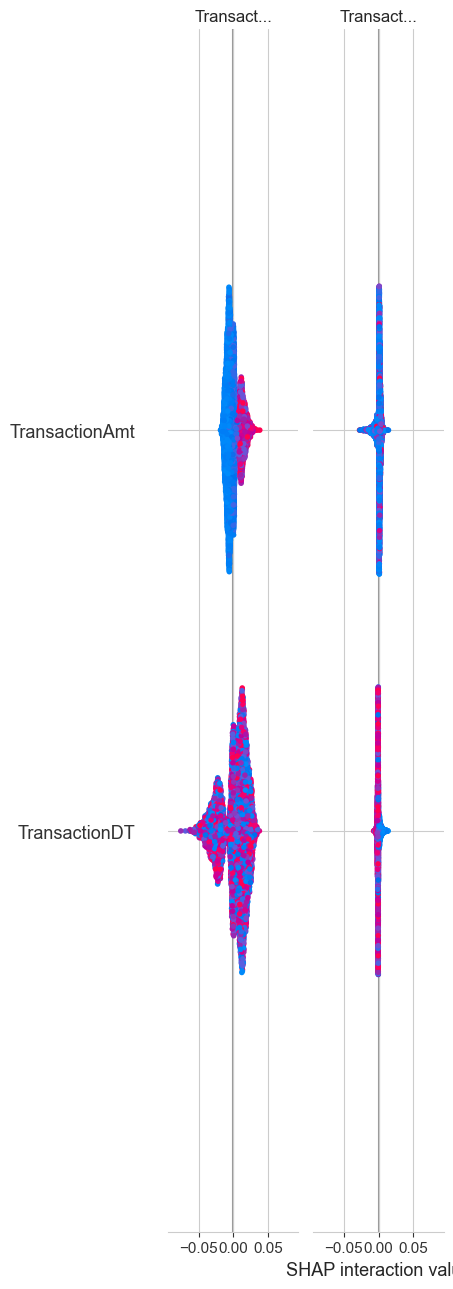

Ã¢Å“â€œ GrÃƒÂ¡fico de importancia SHAP generado


In [ ]:
# Feature importance global
print("\nPlotting SHAP Summary (por magnitud)...")
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.tight_layout()
plt.show()
print("Ã¢Å“â€œ GrÃƒÂ¡fico de importancia SHAP generado")


Generando dependence plots...
Graficando: V282


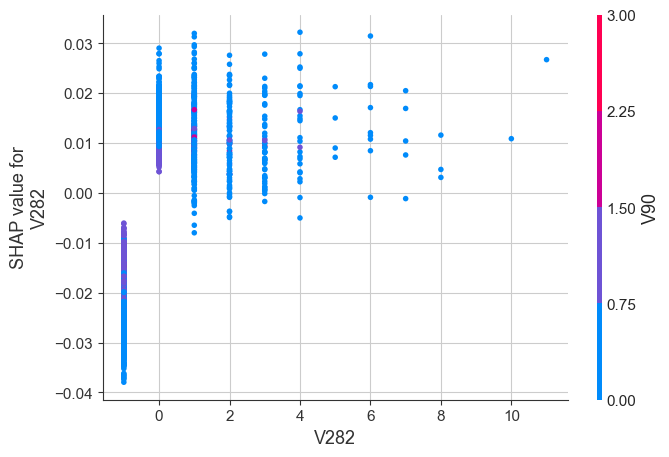

Graficando: V308


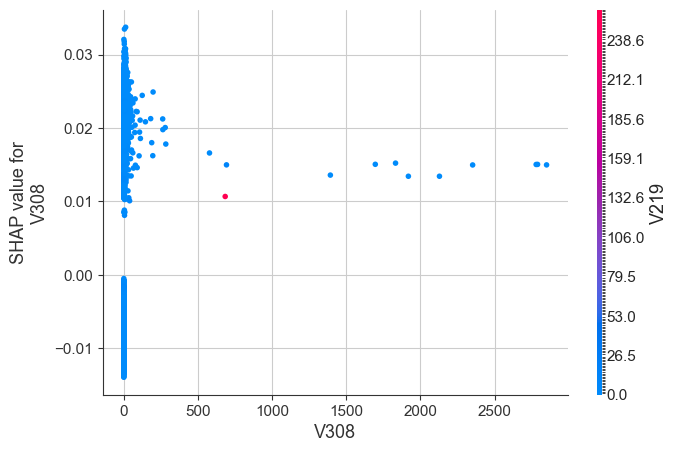

Graficando: V91


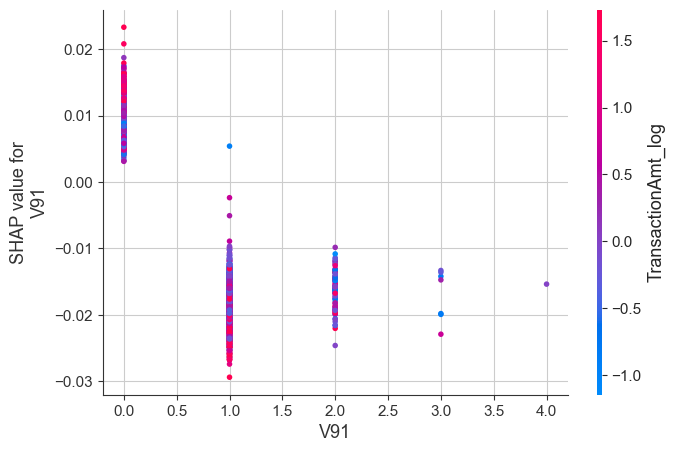

âœ“ Dependence plots generados


In [ ]:
# SHAP Dependence plot (impacto de features)
print("\nGenerando dependence plots...")

# Convertir shap_values a matriz 2D si viene como lista o arreglo 3D
def get_shap_matrix(values, n_samples):
    if isinstance(values, list):
        # En clasificaciÃ³n binaria, normalmente la clase 1 es fraude
        return values[1] if len(values) > 1 else values[0]

    if hasattr(values, "values"):
        values = values.values

    values = np.asarray(values)

    if values.ndim == 3:
        # Formato: samples x features x classes
        if values.shape[0] == n_samples:
            return values[:, :, 1 if values.shape[2] > 1 else 0]

        # Formato: classes x samples x features
        return values[1 if values.shape[0] > 1 else 0, :, :]

    return values


shap_values_plot = get_shap_matrix(shap_values, len(X_sample))

# Tomar top 3 features
top_features_idx = np.argsort(np.abs(shap_values_plot).mean(axis=0))[-3:][::-1]
feature_names = X_sample.columns.tolist()

for idx in top_features_idx:
    print(f"Graficando: {feature_names[idx]}")
    shap.dependence_plot(idx, shap_values_plot, X_sample, show=False)
    plt.show()

print("âœ“ Dependence plots generados")


---
## FASE 9: VALIDACIÃƒâ€œN FINAL Y PREDICCIONES EN TEST
### Pasos 9.1 a 9.4: EvaluaciÃƒÂ³n final

In [ ]:
# Predicciones en test con stacking ensemble
print("Generando predicciones en conjunto de test...")
y_pred_test_proba = meta_learner.predict_proba(X_meta_test)[:, 1]
y_pred_test = (y_pred_test_proba >= 0.5).astype(int)  # Threshold por defecto 0.5

print(f"\nDistribuciÃƒÂ³n de predicciones en test:")
print(f"Predicciones negativas (0): {(y_pred_test == 0).sum():,}")
print(f"Predicciones positivas (1): {(y_pred_test == 1).sum():,}")
print(f"Porcentaje predicho como fraude: {(y_pred_test == 1).sum() / len(y_pred_test) * 100:.2f}%")

Generando predicciones en conjunto de test...

DistribuciÃƒÂ³n de predicciones en test:
Predicciones negativas (0): 496,098
Predicciones positivas (1): 10,593
Porcentaje predicho como fraude: 2.09%


---
## FASE 10: GENERACIÃƒâ€œN DE SUBMISSION
### Pasos 10.1 a 10.3: Guardar resultados

In [ ]:
# Preparar submission
submission = pd.DataFrame({
    'TransactionID': test_transaction['TransactionID'].values,
    'isFraud': y_pred_test_proba
})

# Guardar submission
submission_path = 'submission.csv'
submission.to_csv(submission_path, index=False)

print(f"Ã¢Å“â€œ Submission guardado en {submission_path}")
print(f"\nPrimeras 10 filas:")
print(submission.head(10))

Ã¢Å“â€œ Submission guardado en submission.csv

Primeras 10 filas:
   TransactionID   isFraud
0        3663549  0.002553
1        3663550  0.007864
2        3663551  0.014661
3        3663552  0.002126
4        3663553  0.003176
5        3663554  0.002439
6        3663555  0.005947
7        3663556  0.037973
8        3663557  0.002160
9        3663558  0.009520


In [ ]:
# Guardar modelos entrenados
print("\nGuardando modelos entrenados...")
joblib.dump(base_models_stacking, 'base_models.pkl')
joblib.dump(meta_learner, 'meta_learner.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoders, 'encoders.pkl')

if 'xgb_no_smote' in globals():
    joblib.dump(xgb_no_smote, 'xgb_no_smote.pkl')

print("âœ“ Modelos guardados:")
print("  - base_models.pkl")
print("  - meta_learner.pkl")
print("  - scaler.pkl")
print("  - encoders.pkl")
if 'xgb_no_smote' in globals():
    print("  - xgb_no_smote.pkl")



Guardando modelos entrenados...
âœ“ Modelos guardados:
  - base_models.pkl
  - meta_learner.pkl
  - scaler.pkl
  - encoders.pkl
  - xgb_no_smote.pkl


---
## RESUMEN FINAL Y DOCUMENTACIÃƒâ€œN

In [ ]:
# Resumen del proyecto
print("\n" + "=" * 80)
print(" " * 20 + "RESUMEN FINAL DEL PROYECTO")
print("=" * 80)

print("\nÃ°Å¸â€œÅ  DATASET:")
print(f"   - Registros de entrenamiento: {len(train_data):,}")
print(f"   - Registros de test: {len(test_data):,}")
print(f"   - Variables totales: {train_data.shape[1]}")
print(f"   - Desbalance: 3.5% fraude")

print("\nÃ°Å¸â€Â§ PREPROCESSING:")
print(f"   - Manejo de valores faltantes: Ã¢Å“â€œ")
print(f"   - Encoding de categÃƒÂ³ricas: Ã¢Å“â€œ")
print(f"   - Escalado RobustScaler: Ã¢Å“â€œ")

print("\nÃ¢Å¡â€“Ã¯Â¸Â BALANCEO DE CLASES:")
print(f"   - TÃƒÂ©cnica: SMOTE + Tomek Links")
print(f"   - Muestras despuÃƒÂ©s del balanceo: {len(X_train_balanced):,}")

print("\nÃ°Å¸Â¤â€“ MODELOS ENTRENADOS:")
for i, row in results_df.iterrows():
    print(f"   {i+1}. {row['Modelo']}")
    print(f"      AUC-ROC: {row['AUC-ROC']:.4f} | PrecisiÃƒÂ³n: {row['PrecisiÃƒÂ³n']:.4f} | Recall: {row['Recall']:.4f}")

print("\nÃ°Å¸Ââ€  MODELO FINAL:")
print(f"   - Arquitectura: Stacking Ensemble")
print(f"   - Base Learners: {', '.join(top_3_models)}")
print(f"   - Meta-Learner: Logistic Regression")
print(f"   - AUC-ROC: {stacking_result['AUC-ROC']:.4f}")
print(f"   - AUC-PR: {stacking_result['AUC-PR']:.4f}")
print(f"   - PrecisiÃƒÂ³n: {stacking_result['PrecisiÃƒÂ³n']:.4f}")
print(f"   - Recall: {stacking_result['Recall']:.4f}")
print(f"   - F1-Score: {stacking_result['F1-Score']:.4f}")

print("\nÃ°Å¸â€œÂ ARCHIVOS GENERADOS:")
print(f"   - submission.csv (predicciones en test)")
print(f"   - base_models.pkl (modelos base)")
print(f"   - meta_learner.pkl (meta-learner)")
print(f"   - scaler.pkl (escalador)")
print(f"   - encoders.pkl (encoders)")

print("\n" + "=" * 80)
print("Ã¢Å“â€œ PROYECTO COMPLETADO")
print("=" * 80)


                    RESUMEN FINAL DEL PROYECTO

Ã°Å¸â€œÅ  DATASET:
   - Registros de entrenamiento: 590,540
   - Registros de test: 506,691
   - Variables totales: 584
   - Desbalance: 3.5% fraude

Ã°Å¸â€Â§ PREPROCESSING:
   - Manejo de valores faltantes: Ã¢Å“â€œ
   - Encoding de categÃƒÂ³ricas: Ã¢Å“â€œ
   - Escalado RobustScaler: Ã¢Å“â€œ

Ã¢Å¡â€“Ã¯Â¸Â BALANCEO DE CLASES:
   - TÃƒÂ©cnica: SMOTE + Tomek Links
   - Muestras despuÃƒÂ©s del balanceo: 1,137,432

Ã°Å¸Â¤â€“ MODELOS ENTRENADOS:
   1. Decision Tree
      AUC-ROC: 0.8754 | PrecisiÃƒÂ³n: 0.5025 | Recall: 0.5640
   2. Logistic Regression
      AUC-ROC: 0.7914 | PrecisiÃƒÂ³n: 0.1260 | Recall: 0.5890
   3. Random Forest
      AUC-ROC: 0.9492 | PrecisiÃƒÂ³n: 0.7263 | Recall: 0.6544
   4. XGBoost
      AUC-ROC: 0.9131 | PrecisiÃƒÂ³n: 0.7774 | Recall: 0.4354
   5. LightGBM
      AUC-ROC: 0.9066 | PrecisiÃƒÂ³n: 0.7608 | Recall: 0.4080
   6. CatBoost
      AUC-ROC: 0.9301 | PrecisiÃƒÂ³n: 0.8753 | Recall: 0.4694

Ã°Å¸Ââ€  MODELO FINAL